In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


from pathlib import Path
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split

# ── Config ─────────────────────────────────────────────────────────────────────
# MACRO_COLS = [
#     'CPI_Change', 'Rate_Change', 'GDP_Growth',
#     'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread'
# ]
MACRO_COLS = [
    'CPI_Change', 'Rate_Change', 'GDP_Growth',
    'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread'
]
# LAGGED_COLS = [
#     'CPI_Change_lag1', 'GDP_Growth_lag2',
#     'Unemp_Change_lag1', 'Credit_Spread_lag2'
# ]
LAGGED_COLS = [
        'CPI_Change_lag1', 'GDP_Growth_lag2',
    'Unemp_Change_lag1', 'Credit_Spread_lag2'
]
ALL_COLS = MACRO_COLS + LAGGED_COLS
TARGET   = 'SP500_Return'
SEED     = 42


df = pd.read_csv('../data/processed/processed_data.csv', parse_dates=['Date'])

# ── Data split ─────────────────────────────────────────────────────────────────
splits_data = data_split(df, ALL_COLS)
X_train = splits_data['X_train']
y_train = splits_data['y_train']
X_test  = splits_data['X_test']
y_test  = splits_data['y_test']

print(f"  Training samples : {len(X_train)}")
print(f"  Test samples     : {len(X_test)}")
print(f"  Features         : {len(ALL_COLS)}")


  Train       n= 346  1991-03-01 to 2019-12-01  μ=0.63%  σ=4.08%

  Test        n=  69  2020-01-01 to 2025-09-01  μ=1.05%  σ=5.02%

  Features (7): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread
  Training samples : 346
  Test samples     : 69
  Features         : 7


In [37]:
from random import randint
from random import uniform

# rf_baseline.py


# ── Baseline params ────────────────────────────────────────────────────────────
# Sensible defaults — no tuning yet
# RF_PARAMS = {
#     'n_estimators'     : 100,    # number of trees — more is generally better
#     'max_depth'        : 8,   # grow until pure leaves (will tune later)
#     'min_samples_split': 10,      # minimum samples required to split a node
#     'min_samples_leaf' : 20,      # minimum samples at each leaf
#     'max_features'     : 'sqrt', # features per tree: sqrt(11) ≈ 3 features
#     'bootstrap'        : True,   # sample rows with replacement (bagging)
#     'oob_score'        : True,   # free validation using out-of-bag samples
#     'n_jobs'           : -1,     # use all CPU cores
# }

# RF_PARAMS = {
#     'n_estimators'     : 300,
#     'max_depth'        : 8,
#     'min_samples_split': 20,
#     'min_samples_leaf' : 10,
#     'max_features'     : 0.5,
#     'bootstrap'        : True,
#     'oob_score'        : True,
#     'n_jobs'           : -1,
# }

RF_PARAMS = {
    'n_estimators'     : 100,

    # Force shallow trees — this is the most important fix
    # None caused the overfitting, remove it from the search space
    'max_depth'        : 3,

    # Push these higher — forces trees to generalise more
    'min_samples_split': 20,    # was 2–20, now 10–40
    'min_samples_leaf' : 10,     # was 1–10,  now 5–20

    'max_features'     : 'sqrt',
    # ['sqrt', 'log2', 0.5, 0.7],
    'max_samples'      : 0.5,
}

print("\n── Random Forest Baseline Params ──")
for k, v in RF_PARAMS.items():
    print(f"  {k:<22}: {v}")

# ── Train ──────────────────────────────────────────────────────────────────────
print("\n── Training Random Forest ──")
rf_model = RandomForestRegressor(**RF_PARAMS)
rf_model.fit(X_train, y_train)

# print(f"  OOB R² (free cross-val estimate) : {rf_model.oob_score_:.4f}")

# ── Predictions ────────────────────────────────────────────────────────────────
y_pred_train = rf_model.predict(X_train)
y_pred_test  = rf_model.predict(X_test)

# ── Metrics helper ─────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label):
    r2      = r2_score(y_true, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
    print(f"\n  [{label}]")
    print(f"    R²                   : {r2:.4f}")
    print(f"    RMSE                 : {rmse:.4f}%")
    print(f"    MAE                  : {mae:.4f}%")
    print(f"    Directional accuracy : {dir_acc:.4f}  ({dir_acc*100:.1f}%)")
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'Dir_Acc': dir_acc}

print("\n── Evaluation ──")
train_m = compute_metrics(y_train, y_pred_train, 'Train')
test_m  = compute_metrics(y_test,  y_pred_test,  'Test')




── Random Forest Baseline Params ──
  n_estimators          : 100
  max_depth             : 3
  min_samples_split     : 20
  min_samples_leaf      : 10
  max_features          : sqrt
  max_samples           : 0.5

── Training Random Forest ──

── Evaluation ──

  [Train]
    R²                   : 0.3154
    RMSE                 : 3.3769%
    MAE                  : 2.4945%
    Directional accuracy : 0.7688  (76.9%)

  [Test]
    R²                   : 0.1949
    RMSE                 : 4.5032%
    MAE                  : 3.5188%
    Directional accuracy : 0.7391  (73.9%)


In [38]:
# ── Feature importance ─────────────────────────────────────────────────────────
imp_df = pd.DataFrame({
    'Feature' : ALL_COLS,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
imp_df['Importance_pct'] = imp_df['Importance'] * 100

print("\n── Feature Importance (Mean Decrease in Impurity) ──")
print(imp_df.to_string(index=False))


── Feature Importance (Mean Decrease in Impurity) ──
      Feature  Importance  Importance_pct
   VIX_Change    0.517232       51.723151
Credit_Spread    0.116474       11.647358
   USD_Change    0.115004       11.500383
   GDP_Growth    0.102344       10.234418
  Rate_Change    0.065443        6.544341
   CPI_Change    0.062365        6.236510
 Unemp_Change    0.021138        2.113839


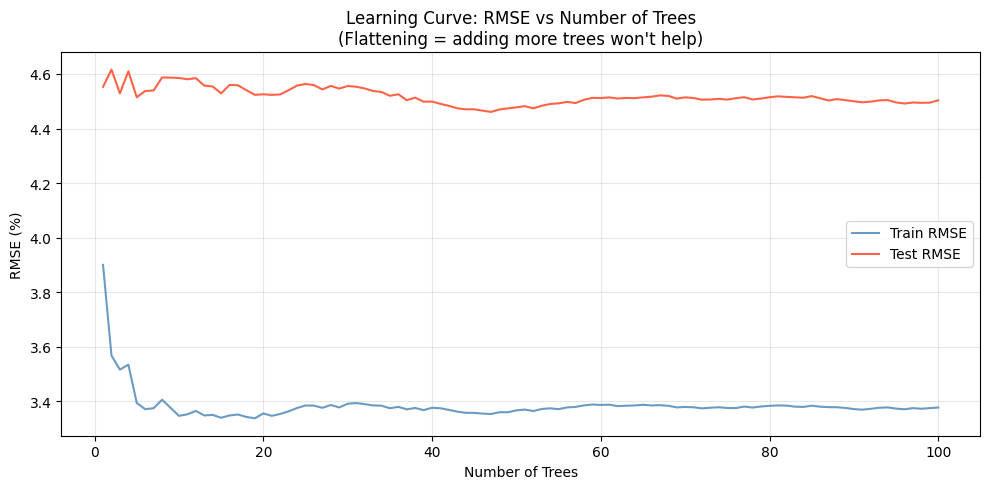

In [39]:

def plot_learning_curve_rf(rf_model, X_train, y_train, X_test, y_test):
    """RMSE vs number of trees — shows when adding more trees stops helping."""
    fig, ax = plt.subplots(figsize=(10, 5))

    train_errors, test_errors = [], []
    # estimators_ gives access to each tree as it was added
    for n, preds in enumerate(rf_model.estimators_, 1):
        # Accumulate predictions tree-by-tree using the first n trees
        y_tr = np.mean([t.predict(X_train) for t in rf_model.estimators_[:n]], axis=0)
        y_te = np.mean([t.predict(X_test)  for t in rf_model.estimators_[:n]], axis=0)
        train_errors.append(np.sqrt(mean_squared_error(y_train, y_tr)))
        test_errors.append( np.sqrt(mean_squared_error(y_test,  y_te)))

    rounds = range(1, len(train_errors) + 1)
    ax.plot(rounds, train_errors, color='steelblue', linewidth=1.5, label='Train RMSE', alpha=0.8)
    ax.plot(rounds, test_errors,  color='tomato',    linewidth=1.5, label='Test RMSE')
    ax.set_xlabel('Number of Trees')
    ax.set_ylabel('RMSE (%)')
    ax.set_title('Learning Curve: RMSE vs Number of Trees\n(Flattening = adding more trees won\'t help)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_feature_importance_rf(imp_df):
    """Horizontal bar chart of mean decrease in impurity."""
    fig, ax = plt.subplots(figsize=(7, 5))
    imp_plot = imp_df.sort_values('Importance_pct')
    bar_cols = ['#2ecc71' if v > imp_df['Importance_pct'].median() else '#3498db'
                for v in imp_plot['Importance_pct']]

    ax.barh(range(len(imp_plot)), imp_plot['Importance_pct'],
            color=bar_cols, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(imp_plot)))
    ax.set_yticklabels(imp_plot['Feature'], fontsize=9)
    ax.set_title('Feature Importance (Mean Decrease in Impurity)\nGreen = above median')
    ax.set_xlabel('Importance (%)')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    return fig


def plot_actual_vs_predicted_rf(test_dates, y_test, y_pred_test, test_m):
    """Time-series overlay of actual vs predicted returns."""
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(test_dates, y_test.values, label='Actual',    color='steelblue', linewidth=2)
    ax.plot(test_dates, y_pred_test,   label='Predicted', color='tomato',
            linewidth=2, linestyle='--', alpha=0.9)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.fill_between(test_dates, y_test.values, y_pred_test,
                    alpha=0.12, color='purple', label='Error')
    ax.set_title(f'Test Set — Actual vs Predicted\n'
                 f"R²={test_m['R2']:.4f}  |  RMSE={test_m['RMSE']:.4f}%  "
                 f"|  Dir.Acc={test_m['Dir_Acc']:.4f}")
    ax.set_ylabel('Monthly Return (%)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_scatter_rf(y_test, y_pred_test, test_m):
    """Scatter of predicted vs actual with perfect-fit diagonal."""
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(y_test, y_pred_test, alpha=0.7, color='mediumseagreen',
               s=60, edgecolors='white', linewidths=0.8, zorder=3)
    lims = [min(y_test.min(), y_pred_test.min()) - 1,
            max(y_test.max(), y_pred_test.max()) + 1]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit', alpha=0.7)
    ax.set_xlabel('Actual Return (%)'); ax.set_ylabel('Predicted (%)')
    ax.set_title(f'Test Set Scatter\nR²={test_m["R2"]:.4f}')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_r2_comparison_rf(train_m, test_m, oob_score):
    """Bar chart of R² across train, OOB, and test."""
    fig, ax = plt.subplots(figsize=(6, 5))
    splits  = ['Train', 'OOB', 'Test']
    r2_vals = [train_m['R2'], oob_score, test_m['R2']]
    colors  = ['steelblue', 'darkorange', 'mediumseagreen']

    bars = ax.bar(splits, r2_vals, color=colors, edgecolor='white', width=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('R² Across Splits\n(OOB = free out-of-bag estimate)')
    ax.set_ylabel('R²')
    ax.set_ylim(min(0, min(r2_vals)) - 0.1, 1.1)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    return fig


def plot_directional_accuracy_rf(train_m, test_m):
    """Bar chart of directional accuracy vs 0.5 random baseline."""
    fig, ax = plt.subplots(figsize=(6, 5))
    splits  = ['Train', 'Test']
    da_vals = [train_m['Dir_Acc'], test_m['Dir_Acc']]
    colors  = ['steelblue', 'mediumseagreen']

    bars = ax.bar(splits, da_vals, color=colors, edgecolor='white', width=0.5)
    ax.axhline(0.50, color='red', linestyle='--', linewidth=1.5, label='Random (0.5)')
    ax.set_ylim(0, 1.1)
    ax.set_title('Directional Accuracy\n(> 0.5 = beats random)')
    ax.set_ylabel('Fraction Correct')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, da_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    return fig


def plot_residuals_rf(y_train, y_pred_train, y_test, y_pred_test):
    """Overlapping residual histograms for train and test."""
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.hist(y_train.values - y_pred_train, bins=25, alpha=0.5,
            color='steelblue',      label='Train', density=True)
    ax.hist(y_test.values  - y_pred_test,  bins=10, alpha=0.7,
            color='mediumseagreen', label='Test',  density=True)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title('Residual Distributions\n(Centred on 0 = unbiased)')
    ax.set_xlabel('Residual (%)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    return fig


plot_learning_curve_rf(rf_model, X_train, y_train, X_test, y_test)

# ── Generate all plots ─────────────────────────────────────────────────────────
# Note: learning curve loop is slow for 500 trees — comment out if needed
# fig1 = plot_learning_curve_rf(rf_model, X_train, y_train, X_test, y_test)
# fig2 = plot_feature_importance_rf(imp_df)
# fig3 = plot_actual_vs_predicted_rf(test_dates, y_test, y_pred_test, test_m)
# fig4 = plot_scatter_rf(y_test, y_pred_test, test_m)
# fig5 = plot_r2_comparison_rf(train_m, test_m, rf_model.oob_score_)
# fig6 = plot_directional_accuracy_rf(train_m, test_m)
# fig7 = plot_residuals_rf(y_train, y_pred_train, y_test, y_pred_test)


plt.show()